# Level shift inspection

**Goal.** Pin down *where* the distributional drift happens that pushes the reconstruction MSE of both PCA (NB 11) and LSTM-AE v4 (NB 12) above the val-tuned threshold in the second half of `test_intern`, and check whether the Kaggle `test.parquet` continues that drift.

**Data inputs.**
| Split | Source | Rows | Labels |
|---|---|---:|:-:|
| train     | `data/raw/train.parquet[0 : 10_309_824]`            | 10,309,824 | yes |
| val       | `data/raw/train.parquet[10_309_824 : 12_542_101]`   | 2,232,277  | yes |
| test_intern | `data/raw/train.parquet[12_542_101 : 14_728_321]` | 2,186,220  | yes |
| kaggle_test | `data/raw/test.parquet` (disjoint file)             | 521,280    | no  |

Split boundaries are pulled from `data/processed/preprocessing_config.json` (chronological 70/15/15 built by NB 02).

**Outputs.**
1. A per-split summary table (mean, std, min, max) → numeric drift evidence.
2. Full-timeline **rolling-mean/±std** plots per channel, with split boundaries and anomaly bands drawn in.
3. Per-split **KDE distributions** per channel so a mean shift vs a variance shift can be told apart.

## Setup

In [1]:
import sys, json
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sentinel.params import ANOMALY_COLOR, NOMINAL_COLOR

sns.set_style('whitegrid')

TRAIN_PARQUET = '../data/raw/train.parquet'
TEST_PARQUET  = '../data/raw/test.parquet'
PREP_CONFIG   = '../data/processed/preprocessing_config.json'

#CHECK_CHANNELS = ['channel_14', 'channel_15', 'channel_21', 'channel_22']
CHECK_CHANNELS = ['channel_14', 'channel_21', 'channel_29', 'channel_30', 'channel_38', 'channel_41', 'channel_60']
WINDOW         = 50_000   # rolling window, full-resolution rows
DOWNSAMPLE     = 50       # keep every Nth row for display (14.7M rows → ~290k plotted)

# Split colours for the summary / KDE plots (fixed across figures for readability)
SPLIT_COLORS = {
    'train':       '#2980b9',
    'val':         '#27ae60',
    'test_intern': '#e67e22',
    'kaggle_test': '#8e44ad',
}

## 1 - Load and split

In [2]:
with open(PREP_CONFIG) as f:
    cfg = json.load(f)

SPLIT_TRAIN_IDX = cfg['split_train_idx']  # end of train
SPLIT_VAL_IDX   = cfg['split_val_idx']    # end of val

print(f'split_train_idx (train | val boundary)        = {SPLIT_TRAIN_IDX:,}')
print(f'split_val_idx   (val   | test_intern boundary) = {SPLIT_VAL_IDX:,}')

cols = CHECK_CHANNELS + ['is_anomaly']
train_df = pd.read_parquet(TRAIN_PARQUET, columns=cols)
test_df  = pd.read_parquet(TEST_PARQUET,  columns=CHECK_CHANNELS)

print(f'\ntrain.parquet: {len(train_df):,} rows')
print(f'test.parquet : {len(test_df):,} rows (no labels)')

split_train_idx (train | val boundary)        = 10,309,824
split_val_idx   (val   | test_intern boundary) = 12,542,101

train.parquet: 14,728,321 rows
test.parquet : 521,280 rows (no labels)


In [3]:
# Slice the single train.parquet into its three internal splits.
splits = {
    'train'      : train_df.iloc[:SPLIT_TRAIN_IDX],
    'val'        : train_df.iloc[SPLIT_TRAIN_IDX:SPLIT_VAL_IDX],
    'test_intern': train_df.iloc[SPLIT_VAL_IDX:],
    'kaggle_test': test_df,
}

for name, df in splits.items():
    n_anom = int(df['is_anomaly'].sum()) if 'is_anomaly' in df.columns else 0
    print(f'{name:12s}  rows={len(df):>12,}  anomalies={n_anom:>10,}')

train         rows=  10,309,824  anomalies= 1,082,680
val           rows=   2,232,277  anomalies=   246,463
test_intern   rows=   2,186,220  anomalies=   214,961
kaggle_test   rows=     521,280  anomalies=         0


## 2 - Per-split summary statistics (numeric drift evidence)

For each channel and each split, compute the nominal-only mean / std / min / max. Anomalies are excluded where labels are available so the comparison is about the *baseline* signal, not about anomalous excursions. For `kaggle_test` (no labels) all rows are used.

If the mean shifts more than a handful of standard deviations between splits, a reconstruction model fit on the earlier split will systematically over-predict the error in the later split — which is exactly the NB 14 pathology.

In [4]:
def nominal_stats(df: pd.DataFrame, channels: list[str]) -> pd.DataFrame:
    '''Mean/std/min/max per channel on nominal rows only (or all rows if unlabelled).'''
    if 'is_anomaly' in df.columns:
        sub = df.loc[df['is_anomaly'] == 0, channels]
    else:
        sub = df[channels]
    return sub.agg(['mean', 'std', 'min', 'max']).T

rows = []
for split_name, df in splits.items():
    s = nominal_stats(df, CHECK_CHANNELS).reset_index().rename(columns={'index': 'channel'})
    s.insert(0, 'split', split_name)
    rows.append(s)

stats = pd.concat(rows, ignore_index=True)
stats_wide = stats.set_index(['channel', 'split'])[['mean', 'std', 'min', 'max']].unstack('split')
stats_wide = stats_wide.swaplevel(axis=1).sort_index(axis=1, level=0)
stats_wide.round(8)

split      kaggle_test                               test_intern            \
                   max      mean       min       std         max      mean   
channel                                                                      
channel_14    0.700417  0.640148  0.575246  0.016208    0.808676  0.355872   
channel_21    0.700417  0.651886  0.587088  0.016337    0.808676  0.361378   
channel_29    0.700417  0.643078  0.578628  0.016118    0.808676  0.370712   
channel_30    0.514351  0.425341  0.390874  0.014090    0.592166  0.227365   
channel_38    0.538036  0.421080  0.390874  0.013995    0.592166  0.226248   
channel_41    0.957780  0.807722  0.793574  0.004847    0.821213  0.808345   
channel_60    0.833320  0.731368  0.710603  0.024026    0.847974  0.781021   

split                              train                                \
                 min       std       max      mean       min       std   
channel                                                                  
channel_14  0.178021  0.149644  0.402717  0.254221  0.122198  0.058630   
channel_21  0.181036  0.153276  0.429778  0.260556  0.123711  0.059670   
channel_29  0.205176  0.143768  0.409482  0.274993  0.149359  0.054815   
channel_30  0.099571  0.108616  0.254958  0.135806  0.033190  0.053109   
channel_38  0.099571  0.107303  0.254958  0.135402  0.033190  0.053241   
channel_41  0.793742  0.005008  0.825136  0.810742  0.793742  0.004993   
channel_60  0.716097  0.038773  0.760055  0.711588  0.669765  0.019892   

split            val                                
                 max      mean       min       std  
channel                                             
channel_14  0.375649  0.258266  0.132761  0.063140  
channel_21  0.375649  0.264366  0.134268  0.065019  
channel_29  0.375649  0.276997  0.156902  0.058553  
channel_30  0.224789  0.141172  0.052803  0.050102  
channel_38  0.224789  0.140850  0.052803  0.050222  
channel_41  0.818072  0.806794  0.793742  0.004859  
channel_60  0.760055  0.707286  0.682212  0.017258

In [5]:
# Compact drift table: relative mean shift of every split vs the train baseline.
train_stats = stats[stats['split'] == 'train'].set_index('channel')[['mean', 'std']]
train_stats.columns = ['train_mean', 'train_std']

drift = stats.merge(train_stats, left_on='channel', right_index=True)
drift['mean_delta']   = drift['mean'] - drift['train_mean']
drift['mean_delta_z'] = drift['mean_delta'] / drift['train_std']
drift['std_ratio']    = drift['std'] / drift['train_std']

summary = drift[drift['split'] != 'train'].pivot(
    index='channel', columns='split', values=['mean_delta', 'mean_delta_z', 'std_ratio']
).round(3)
print('Drift relative to train baseline:')
print('  mean_delta    — raw difference in means (split − train)')
print('  mean_delta_z  — same difference in train-std units (|z| ≳ 1 = visible drift)')
print('  std_ratio     — split_std / train_std  (values far from 1.0 = variance shift)')
summary

Drift relative to train baseline:
  mean_delta    — raw difference in means (split − train)
  mean_delta_z  — same difference in train-std units (|z| ≳ 1 = visible drift)
  std_ratio     — split_std / train_std  (values far from 1.0 = variance shift)


mean_delta                    mean_delta_z                     \
split      kaggle_test test_intern    val  kaggle_test test_intern    val   
channel                                                                     
channel_14       0.386       0.102  0.004        6.582       1.734  0.069   
channel_21       0.391       0.101  0.004        6.558       1.690  0.064   
channel_29       0.368       0.096  0.002        6.715       1.746  0.037   
channel_30       0.290       0.092  0.005        5.452       1.724  0.101   
channel_38       0.286       0.091  0.005        5.366       1.706  0.102   
channel_41      -0.003      -0.002 -0.004       -0.605      -0.480 -0.791   
channel_60       0.020       0.069 -0.004        0.994       3.491 -0.216   

             std_ratio                     
split      kaggle_test test_intern    val  
channel                                    
channel_14       0.276       2.552  1.077  
channel_21       0.274       2.569  1.090  
channel_29       0.294       2.623  1.068  
channel_30       0.265       2.045  0.943  
channel_38       0.263       2.015  0.943  
channel_41       0.971       1.003  0.973  
channel_60       1.208       1.949  0.868

## 3 - Continuous timeline with all splits

Plots the full train.parquet followed by the Kaggle test.parquet appended at the end. Split boundaries are drawn as dashed verticals. True-anomaly runs inside train.parquet are shaded. Rolling mean / ±1 std are computed on the downsampled series with a proportionally shrunken window, so the smoothing timescale is the same across the full plot.

The drift should be visible as a step or a drift in the rolling mean / std band — especially near the `val | test_intern` boundary, which is where the reconstruction-MSE step happened in NB 14.

In [6]:
# Concatenate train + Kaggle test into one continuous display DataFrame.
# The Kaggle test is indexed to START right after train.parquet ends, so the
# x-axis stays a single monotonic row counter.
kaggle_offset = len(train_df)
test_shifted  = test_df.copy()
test_shifted.index = test_shifted.index + kaggle_offset

all_df = pd.concat(
    [
        train_df[CHECK_CHANNELS + ['is_anomaly']],
        test_shifted.assign(is_anomaly=np.nan),   # no labels on Kaggle
    ],
    axis=0,
)

# Downsample for display only (rolling stats are per-channel on the downsampled series).
all_ds = all_df.iloc[::DOWNSAMPLE].copy()
win_ds = max(1, WINDOW // DOWNSAMPLE)

# Boundary positions in the combined index
BOUND_TRAIN_VAL   = SPLIT_TRAIN_IDX
BOUND_VAL_TEST    = SPLIT_VAL_IDX
BOUND_KAGGLE_START = kaggle_offset
BOUND_KAGGLE_END   = kaggle_offset + len(test_df)

print(f'Combined timeline: {len(all_df):,} rows → plotting {len(all_ds):,} rows ({DOWNSAMPLE}× downsampled)')
print(f'Boundaries: train│val = {BOUND_TRAIN_VAL:,}   val│test_intern = {BOUND_VAL_TEST:,}   kaggle start = {BOUND_KAGGLE_START:,}')

Combined timeline: 15,249,601 rows → plotting 304,993 rows (50× downsampled)
Boundaries: train│val = 10,309,824   val│test_intern = 12,542,101   kaggle start = 14,728,321


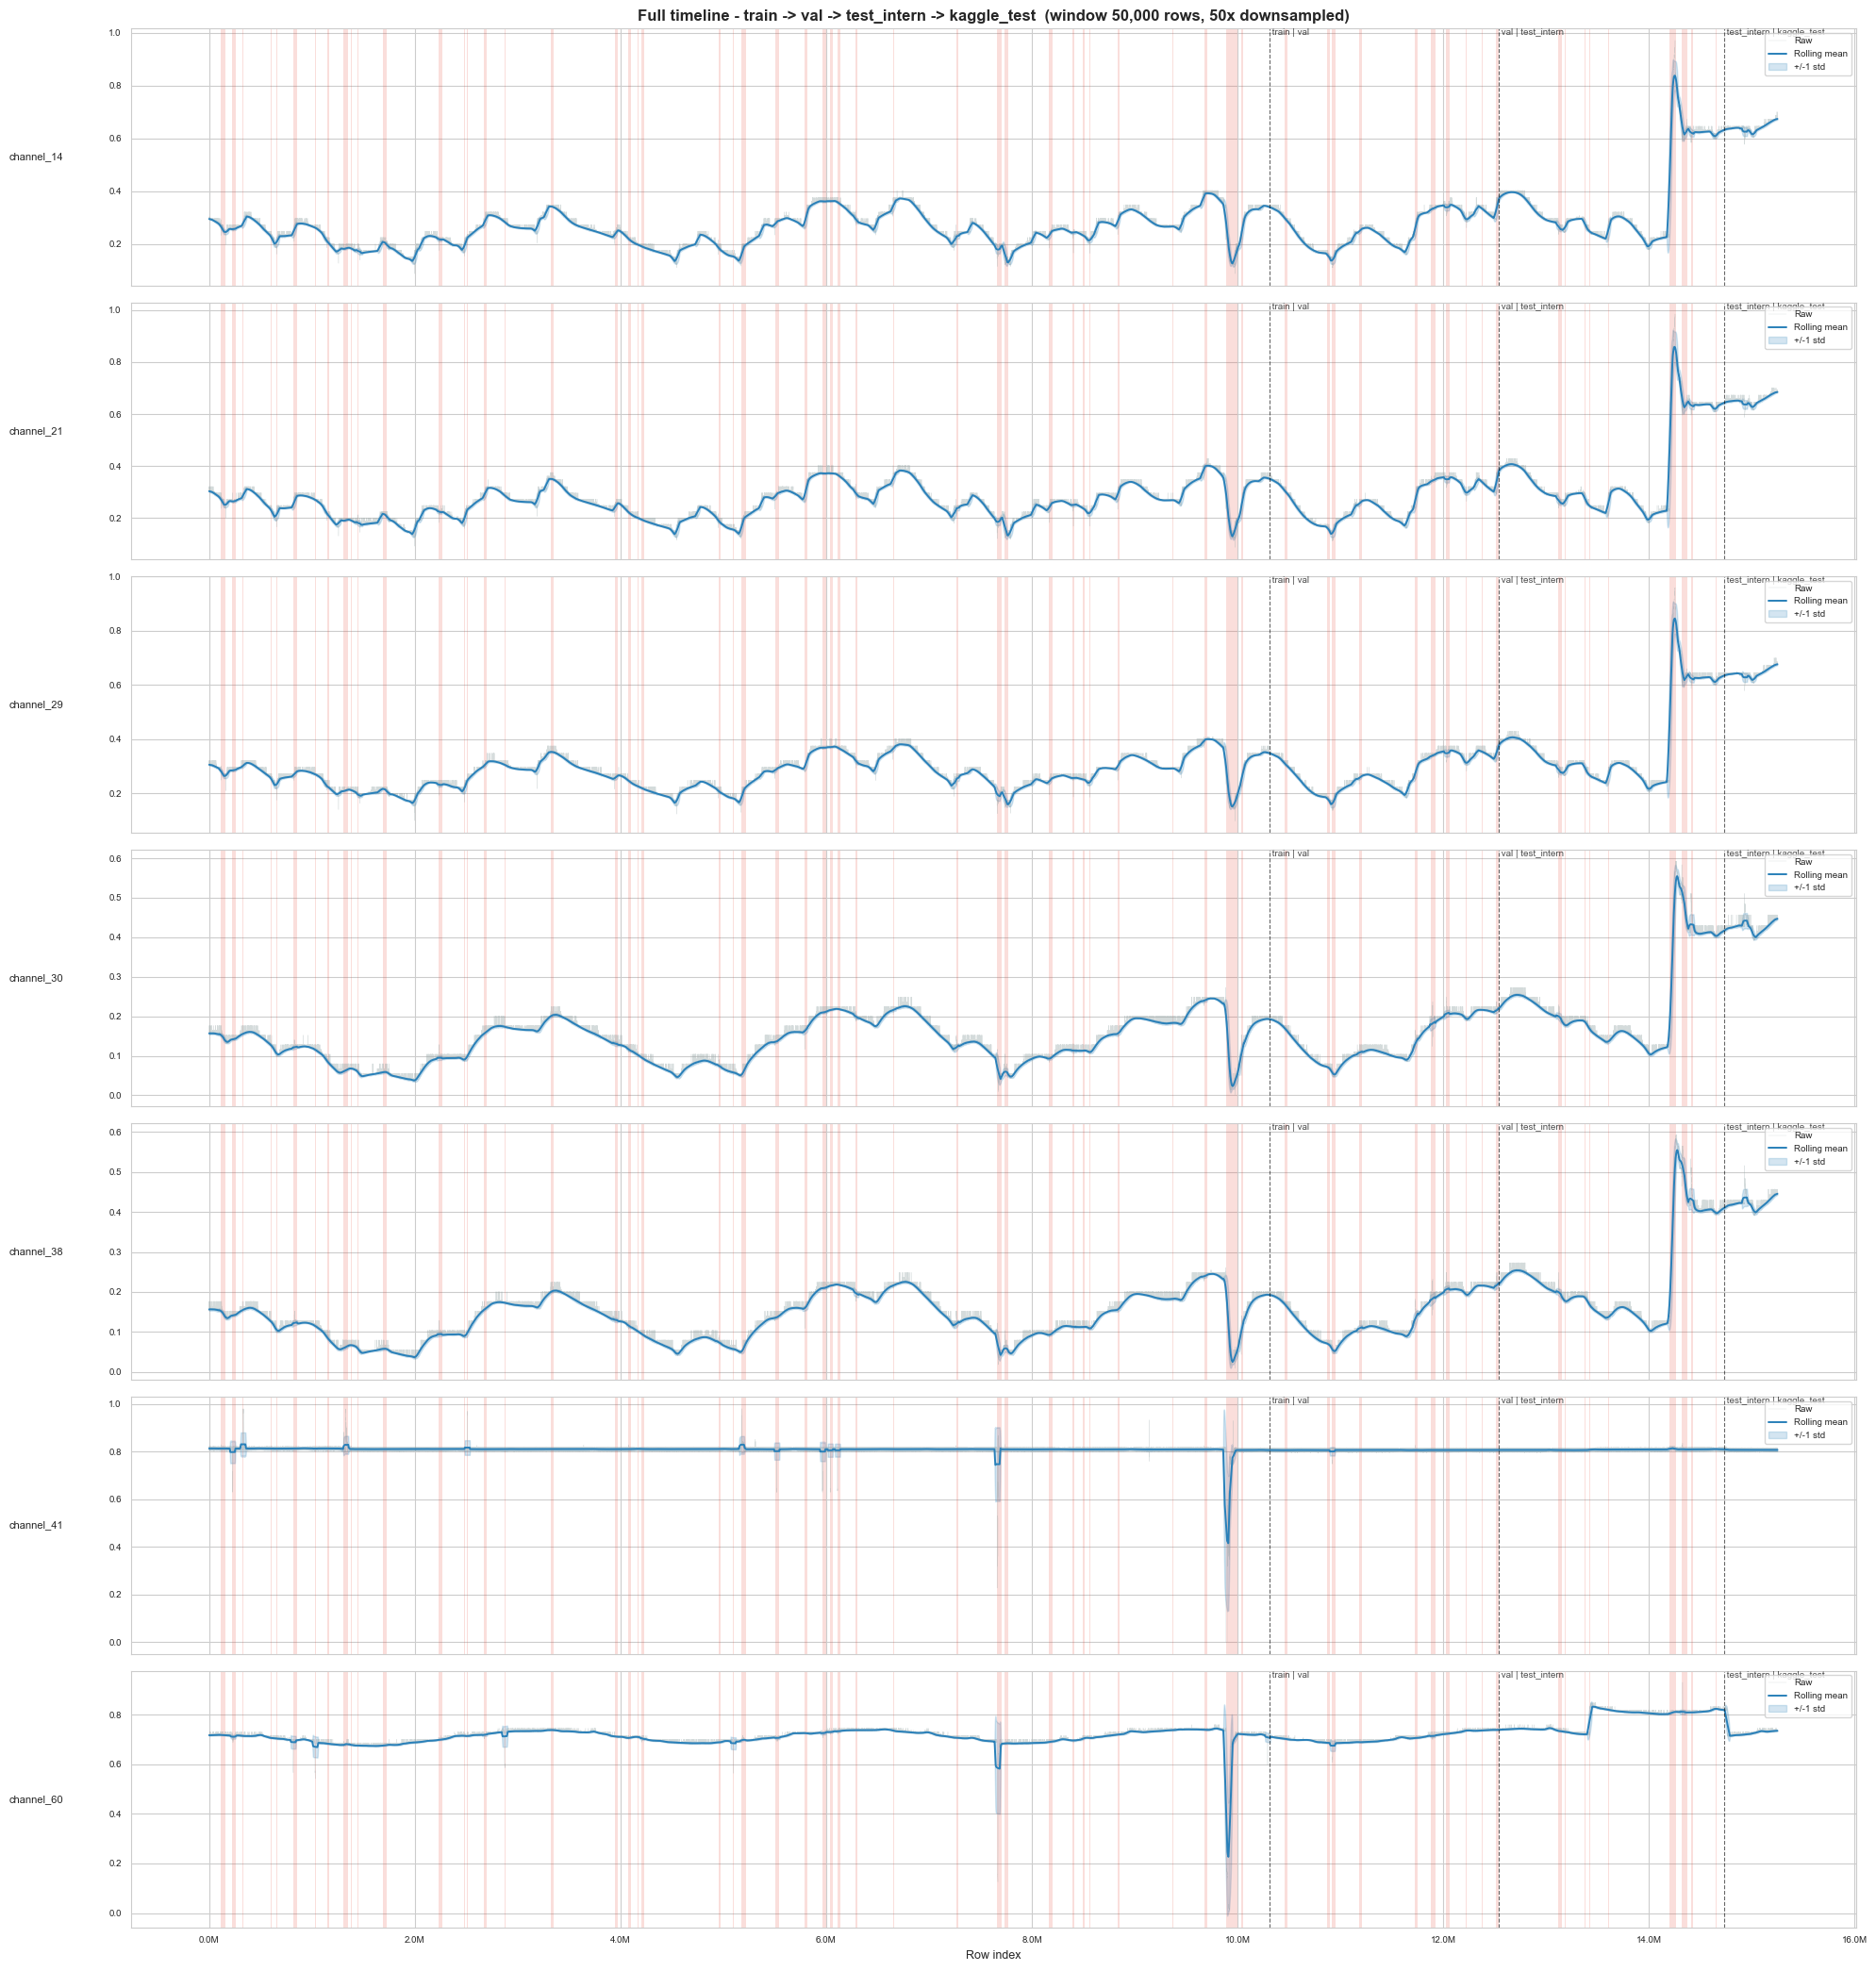

In [7]:
def plot_full_timeline(all_ds: pd.DataFrame, channels: list[str]):
    '''Per-channel panel: raw trace, rolling mean, +/-1 std band, split boundaries, anomaly shading.'''
    fig, axes = plt.subplots(
        len(channels), 1,
        figsize=(20, 3 * len(channels)),
        sharex=True,
    )
    if len(channels) == 1:
        axes = [axes]

    # Anomaly shading: vectorised segment detection via np.diff on the padded
    # binary mask. Each rising edge in diff is a segment start, each falling
    # edge a segment end; we map those indices back to the original axis.
    anom = all_ds['is_anomaly'].fillna(0).astype(int).to_numpy()
    idx_arr = all_ds.index.to_numpy()
    padded = np.concatenate(([0], anom, [0]))
    edges = np.diff(padded)
    seg_starts = np.where(edges == 1)[0]
    seg_ends   = np.where(edges == -1)[0]
    if len(seg_starts):
        end_idx = np.clip(seg_ends, 0, len(idx_arr) - 1)
        span_x0 = idx_arr[seg_starts]
        span_x1 = idx_arr[end_idx]
    else:
        span_x0 = span_x1 = np.empty(0, dtype=idx_arr.dtype)

    for ax, ch in zip(axes, channels):
        roll_mean = all_ds[ch].rolling(win_ds, min_periods=1, center=True).mean()
        roll_std  = all_ds[ch].rolling(win_ds, min_periods=1, center=True).std()

        ax.plot(all_ds.index, all_ds[ch], lw=0.25, color='#95a5a6', alpha=0.4, label='Raw')
        ax.plot(all_ds.index, roll_mean, lw=1.4, color=NOMINAL_COLOR, label='Rolling mean')
        ax.fill_between(all_ds.index, roll_mean - roll_std, roll_mean + roll_std,
                        alpha=0.2, color=NOMINAL_COLOR, label='+/-1 std')

        for x0, x1 in zip(span_x0, span_x1):
            ax.axvspan(x0, x1, color=ANOMALY_COLOR, alpha=0.18, linewidth=0)

        # Split boundary verticals
        for x, label in [
            (BOUND_TRAIN_VAL,    'train | val'),
            (BOUND_VAL_TEST,     'val | test_intern'),
            (BOUND_KAGGLE_START, 'test_intern | kaggle_test'),
        ]:
            ax.axvline(x, color='k', ls='--', lw=0.8, alpha=0.6)
            ax.text(x, ax.get_ylim()[1], f' {label}', fontsize=7, va='top', ha='left', color='k', alpha=0.7)

        ax.set_ylabel(ch, fontsize=8, rotation=0, labelpad=55, va='center')
        ax.legend(fontsize=7, loc='upper right')
        ax.tick_params(labelsize=7)

    axes[0].set_title(
        f'Full timeline - train -> val -> test_intern -> kaggle_test  (window {WINDOW:,} rows, {DOWNSAMPLE}x downsampled)',
        fontsize=12, fontweight='bold',
    )
    axes[-1].set_xlabel('Row index', fontsize=9)
    axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    fig.tight_layout()
    return fig

plot_full_timeline(all_ds, CHECK_CHANNELS)
plt.show()

## 4 - Per-split KDE distributions

**Kernel Density Estimation (KDE)** Overlays the channel-value density for every split on one axis per channel. A pure **horizontal shift** between the train and test_intern / kaggle_test curves is a mean drift; a **different width** is a variance drift. Both matter for reconstruction models — the former moves the MSE baseline, the latter changes how wide the nominal score distribution is.

train         KDE sample =  100,000 nominal rows
val           KDE sample =  100,000 nominal rows
test_intern   KDE sample =  100,000 nominal rows
kaggle_test   KDE sample =  100,000 nominal rows


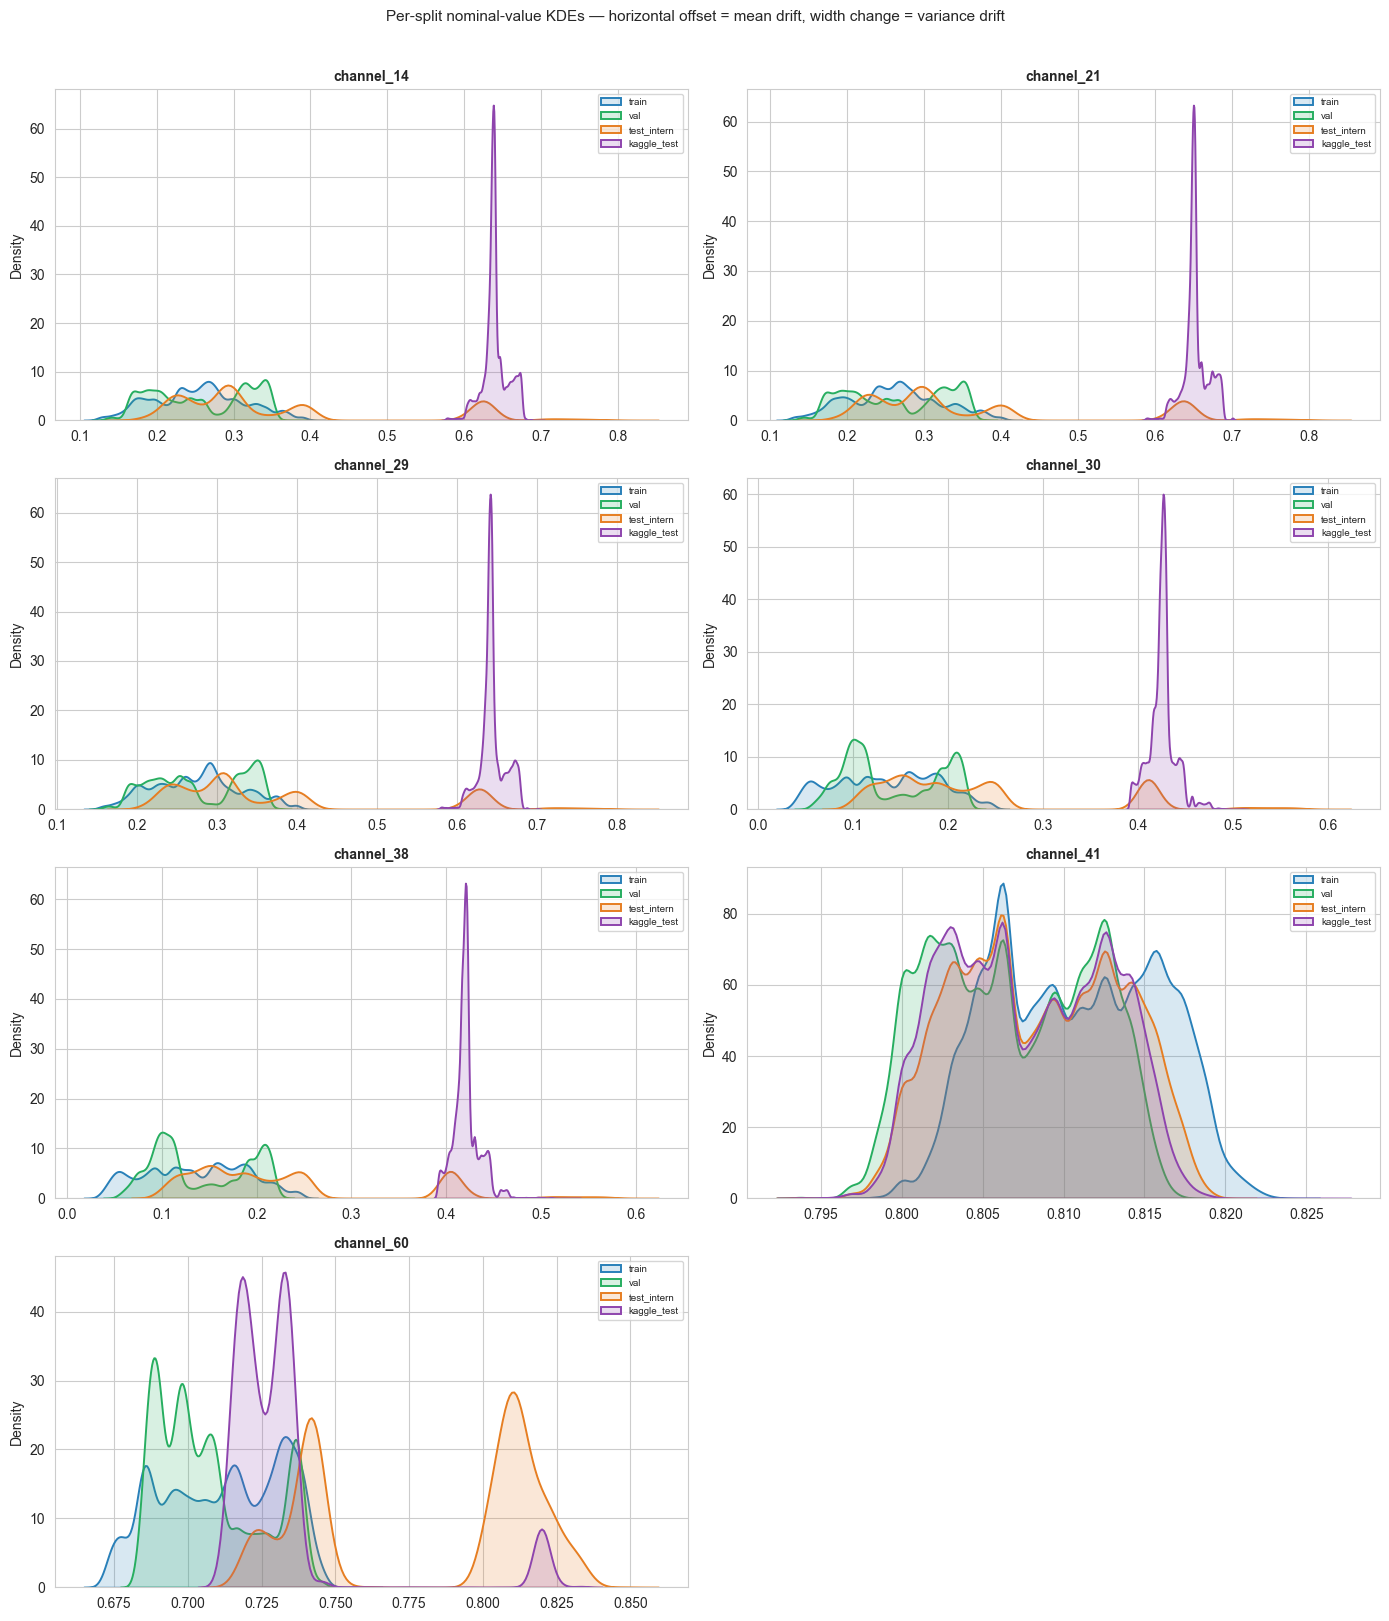

In [8]:
# Sample a comparable number of nominal rows from every split so the KDEs
# aren't distorted by the train split's 10× row count.
KDE_SAMPLE_N = 100_000
rng = np.random.default_rng(42)

samples = {}
for split_name, df in splits.items():
    if 'is_anomaly' in df.columns:
        df = df.loc[df['is_anomaly'] == 0]
    n = min(KDE_SAMPLE_N, len(df))
    samples[split_name] = df.iloc[rng.choice(len(df), n, replace=False)][CHECK_CHANNELS]
    print(f'{split_name:12s}  KDE sample = {len(samples[split_name]):>8,} nominal rows')

ncols = 2
nrows = int(np.ceil(len(CHECK_CHANNELS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).flatten()

for ax, ch in zip(axes, CHECK_CHANNELS):
    for split_name, sample in samples.items():
        sns.kdeplot(
            sample[ch],
            ax=ax, fill=True, alpha=0.18, linewidth=1.4,
            color=SPLIT_COLORS[split_name],
            label=split_name,
        )
    ax.set_title(ch, fontsize=10, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('Density')
    ax.legend(fontsize=7)

for j in range(len(CHECK_CHANNELS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Per-split nominal-value KDEs — horizontal offset = mean drift, width change = variance drift',
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()

## 6 - All 58 channels scan

Quick sweep across **all 58 target channels** to see how widespread the drift is, not just on the four that happened to dominate the LSTM top-k.

The four-channel deep-dive in Sections 2–5 zoomed in on `channel_14/15/21/22`; here we drop the zoom and ask: *which of the 58 channels are actually drifting, and at what size?*

Uses a 10× sampled copy of train.parquet (full `test.parquet`) for speed — ~1.5 M rows across the four splits, enough resolution for nominal mean/std comparisons.

In [9]:
# Sampled 58-channel drift scan. Uses the target channel list from preprocessing_config.
CHANNELS_ALL = cfg['target_channels']
STRIDE = 10

# Re-use the already-opened train_df / test_df if their column sets cover CHANNELS_ALL,
# otherwise re-read with the wider column set.
needed = set(CHANNELS_ALL) - set(train_df.columns)
if needed:
    train_all = pd.read_parquet(TRAIN_PARQUET, columns=CHANNELS_ALL + ['is_anomaly']).iloc[::STRIDE]
    kaggle_all = pd.read_parquet(TEST_PARQUET,  columns=CHANNELS_ALL).iloc[::STRIDE]
else:
    train_all  = train_df[CHANNELS_ALL + ['is_anomaly']].iloc[::STRIDE]
    kaggle_all = test_df[CHANNELS_ALL].iloc[::STRIDE]

S_TV_s = SPLIT_TRAIN_IDX // STRIDE
S_VT_s = SPLIT_VAL_IDX   // STRIDE
splits_all = {
    'train'      : train_all.iloc[:S_TV_s],
    'val'        : train_all.iloc[S_TV_s:S_VT_s],
    'test_intern': train_all.iloc[S_VT_s:],
    'kaggle_test': kaggle_all,
}

def _nom_stats(df):
    if 'is_anomaly' in df.columns:
        sub = df.loc[df['is_anomaly'] == 0, CHANNELS_ALL]
    else:
        sub = df[CHANNELS_ALL]
    return sub.agg(['mean', 'std']).T

tr = _nom_stats(splits_all['train']).rename(columns={'mean': 'tr_mean', 'std': 'tr_std'})
rows = []
for name in ['val', 'test_intern', 'kaggle_test']:
    s  = _nom_stats(splits_all[name])
    z  = (s['mean'] - tr['tr_mean']) / tr['tr_std']
    sr = s['std'] / tr['tr_std']
    rows.append(pd.DataFrame({f'{name}_z': z.round(2), f'{name}_sr': sr.round(2)}))

drift = pd.concat([tr[['tr_mean', 'tr_std']].round(3)] + rows, axis=1)
print(f'Scanned {len(CHANNELS_ALL)} channels across 4 splits.')
drift.head()

Scanned 58 channels across 4 splits.


,tr_mean,tr_std,val_z,val_sr,test_intern_z,test_intern_sr,kaggle_test_z,kaggle_test_sr
channel_12,0.261,0.040,-0.59,0.88,-0.38,1.09,-0.37,0.38
channel_13,0.317,0.040,-0.78,0.87,-0.60,1.11,-0.62,0.37
channel_14,0.254,0.059,0.07,1.08,1.73,2.55,6.58,0.28
channel_15,0.106,0.049,0.21,0.63,1.69,1.70,4.55,0.29
channel_16,0.758,0.072,-0.02,0.85,0.63,0.82,0.81,0.35


In [10]:
# How widespread is the drift?
print('How many of the 58 channels cross each drift threshold?')
print(f'{"|z| >=":>10}  {"val":>6}  {"test_intern":>12}  {"kaggle_test":>12}')
for thr in [0.5, 1.0, 2.0, 5.0]:
    n_val = (drift['val_z'].abs()         >= thr).sum()
    n_ti  = (drift['test_intern_z'].abs() >= thr).sum()
    n_kag = (drift['kaggle_test_z'].abs() >= thr).sum()
    print(f'{thr:>10.1f}  {n_val:>6}  {n_ti:>12}  {n_kag:>12}')

# Top-15 worst offenders on each split
def _show_top(sort_col, title):
    top = drift.reindex(drift[sort_col].abs().sort_values(ascending=False).index).head(15)
    cols = ['tr_mean', 'tr_std',
            'val_z', 'test_intern_z', 'kaggle_test_z',
            'val_sr', 'test_intern_sr', 'kaggle_test_sr']
    print(f'\n--- {title} ---')
    print(top[cols].to_string())

_show_top('kaggle_test_z',  'Top 15 by |kaggle_test_z| (leaderboard drift)')
_show_top('test_intern_z',  'Top 15 by |test_intern_z| (internal drift, NB 14 pathology)')

# 'Quiet' channels: no meaningful drift anywhere
quiet = drift[
    (drift['val_z'].abs()         < 0.5) &
    (drift['test_intern_z'].abs() < 0.5) &
    (drift['kaggle_test_z'].abs() < 0.5) &
    ((drift['val_sr']        - 1).abs() < 0.3) &
    ((drift['test_intern_sr']- 1).abs() < 0.3) &
    ((drift['kaggle_test_sr']- 1).abs() < 0.3)
]
print(f'\n--- {len(quiet)} / {len(drift)} quiet channels (|z| < 0.5 and |sr-1| < 0.3 on every split) ---')
print(list(quiet.index))

How many of the 58 channels cross each drift threshold?
    |z| >=     val   test_intern   kaggle_test
       0.5      20            22            26
       1.0       1            14            13
       2.0       0             4            10
       5.0       0             0             7

--- Top 15 by |kaggle_test_z| (leaderboard drift) ---
            tr_mean  tr_std  val_z  test_intern_z  kaggle_test_z  val_sr  test_intern_sr  kaggle_test_sr
channel_29    0.275   0.055   0.04           1.75           6.72    1.07            2.62            0.29
channel_14    0.254   0.059   0.07           1.73           6.58    1.08            2.55            0.28
channel_21    0.261   0.060   0.06           1.69           6.56    1.09            2.57            0.27
channel_30    0.136   0.053   0.10           1.72           5.45    0.94            2.05            0.27
channel_38    0.135   0.053   0.10           1.71           5.37    0.94            2.02            0.26
channel_22    0.323   0.

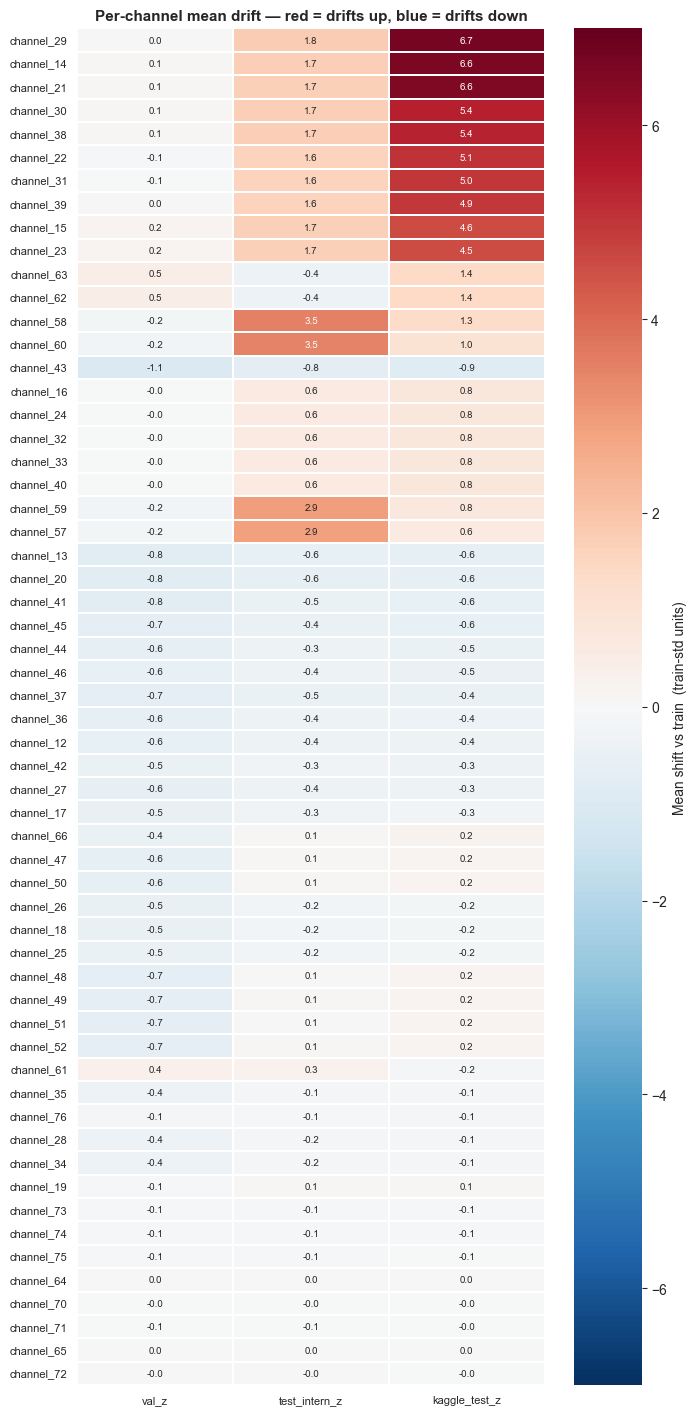

In [11]:
# Heatmap view — channels sorted by |kaggle_test_z| so the worst drifters sit at the top.
order = drift.reindex(drift['kaggle_test_z'].abs().sort_values(ascending=False).index).index
Z = drift.loc[order, ['val_z', 'test_intern_z', 'kaggle_test_z']].astype(float)

fig, ax = plt.subplots(figsize=(7, 0.22 * len(Z) + 1.5))
sns.heatmap(
    Z, ax=ax,
    cmap='RdBu_r', center=0, vmin=-7, vmax=7,
    annot=True, fmt='.1f', annot_kws={'size': 7},
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Mean shift vs train  (train-std units)'},
)
ax.set_title('Per-channel mean drift — red = drifts up, blue = drifts down',
             fontsize=11, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(labelsize=8)
fig.tight_layout()
plt.show()

### Reading the heatmap

**Rows are sorted** by |kaggle_test_z| descending, so the worst leaderboard drifters are at the top.

- **Top cluster (channels 29, 14, 21, 30, 38, 22, 31, 39, 15, 23)** — 10 channels moving in lock-step: ~+1.7 σ on test_intern, +4.5 – 6.7 σ on Kaggle. This is one physical regime change expressed across a correlated subsystem. Top-k reconstruction scoring picks the two most visible (14, 21); fixing only those leaves the other eight still flagging.
- **Low-variance cluster (57, 58, 59, 60)** — largest test_intern drift (|z| up to 3.5) but mild Kaggle drift. Invisible to top-k MSE (small absolute error because `tr_std ≈ 0.020`), but inflates `test_intern` metrics. A test_intern → Kaggle correlation estimate needs to account for these.
- **Quiet channels** (42, 64, 65, 70–75) — stable everywhere. Candidates for a drift-free reference signal.

### Implication for model design

Any detrender needs to cover **14 channels minimum** to address the NB 14 pathology (|test_intern_z| ≥ 1), not the four we originally identified. Since the 10 Group A channels move in lock-step, a single shared detrend factor per row (derived e.g. from their rolling mean) might work as well as per-channel detrending — worth checking.

## 5 - Diagnostic read

Cross-reference the three views above:

1. **Summary table** — any `|mean_delta_z|` clearly above ~1 is a drift strong enough to push a reconstruction model above a val-tuned threshold. `std_ratio` far from 1 widens or narrows the score distribution independently.
2. **Full timeline** — look at the rolling-mean line at the `val | test_intern` boundary (around row 12.5 M). A step or a sustained drift there is the direct cause of the MSE step-change seen in NB 14 at row ≈ 0.9–1.0 M of `test_intern`. A *further* shift at the `test_intern | kaggle_test` boundary (around row 14.7 M) predicts how badly a test-naive submission will collapse on Kaggle.
3. **KDEs** — if train and test_intern curves sit on top of each other but kaggle_test is shifted, the internal split misses the Kaggle drift and `test_intern` F0.5 is systematically optimistic for leaderboard prediction. If train and test_intern are *also* offset, then the internal split already reveals it — and the threshold-tuning strategy (e.g. prior-matching or detrending) chosen on val will transfer to Kaggle.

**Planned next steps based on findings.** If the rolling mean clearly steps at the val|test_intern boundary on any channel:
- Add a rolling-baseline subtraction pre-processor (median filter on the score, see the suggestion in NB 14's diagnostic discussion).
- Re-run the NB 11 / NB 12 scoring on detrended input and compare Row F1 / ESA-corrected F0.5 against the originals in `docs/results.md`.

In [12]:
# Persist the full drift table so downstream notebooks (detrending, rescoring)
# can read it without recomputing.
out_csv = '_drift_scan_all_channels.csv'
drift.to_csv(out_csv)
print(f'Saved: {out_csv}')
drift.head(4)

Saved: _drift_scan_all_channels.csv


,tr_mean,tr_std,val_z,val_sr,test_intern_z,test_intern_sr,kaggle_test_z,kaggle_test_sr
channel_12,0.261,0.040,-0.59,0.88,-0.38,1.09,-0.37,0.38
channel_13,0.317,0.040,-0.78,0.87,-0.60,1.11,-0.62,0.37
channel_14,0.254,0.059,0.07,1.08,1.73,2.55,6.58,0.28
channel_15,0.106,0.049,0.21,0.63,1.69,1.70,4.55,0.29
